# Extra features , Modularity, Assortability and Hierarchical Complexity

In [27]:
import pandas as pd
import pickle

In [53]:
graph_df = pd.read_csv("graph_data.csv")

In [55]:
# Load the graphs from the pickle file
with open("graphs_by_sample.pkl", "rb") as f:
    loaded_graphs = pickle.load(f)

In [56]:
graph_df

,sample,nodes,edges,avg_degree,global_clustering,avg_local_clustering,largest_connected_component,condition,diffusion_efficiency
0,TCGA_Tumor_A3A3,6496,64794,19.95,0.2261,0.6576,6482,Tumor,0.3447
1,TCGA_Tumor_A3RK,6518,65317,20.04,0.2231,0.6584,6504,Tumor,0.3451
2,TCGA_Tumor_A3KG,6480,64995,20.06,0.2257,0.6605,6466,Tumor,0.3450
3,TCGA_Tumor_AAU7,6578,65735,19.99,0.2210,0.6588,6559,Tumor,0.3440
4,TCGA_Tumor_A9VH,6535,65276,19.98,0.2228,0.6580,6516,Tumor,0.3438
...,...,...,...,...,...,...,...,...,...
418,TCGA_Tumor_A5MZ,6532,65397,20.02,0.2221,0.6593,6513,Tumor,0.3443
419,TCGA_Tumor_AACD,6467,64771,20.03,0.2286,0.6581,6450,Tumor,0.3438
420,TCGA_Healthy_A1EG,6462,64684,20.02,0.2284,0.6568,6446,Healthy,0.3440
421,TCGA_Tumor_A73D,6426,64661,20.12,0.2277,0.6605,6407,Tumor,0.3448


In [57]:
loaded_graphs

{'TCGA_Tumor_A3A3': <networkx.classes.graph.Graph at 0x4f5937e00>,
 'TCGA_Tumor_A3RK': <networkx.classes.graph.Graph at 0x4f59352b0>,
 'TCGA_Tumor_A3KG': <networkx.classes.graph.Graph at 0x4f5934230>,
 'TCGA_Tumor_AAU7': <networkx.classes.graph.Graph at 0x4f5936f30>,
 'TCGA_Tumor_A9VH': <networkx.classes.graph.Graph at 0x4f59feea0>,
 'TCGA_Tumor_A5SL': <networkx.classes.graph.Graph at 0x4f59ff320>,
 'TCGA_Healthy_A3CH': <networkx.classes.graph.Graph at 0x4f59ff800>,
 'TCGA_Tumor_AAE0': <networkx.classes.graph.Graph at 0x4f59fc470>,
 'TCGA_Tumor_A4NO': <networkx.classes.graph.Graph at 0x4f59fc3b0>,
 'TCGA_Tumor_A9GS': <networkx.classes.graph.Graph at 0x4f59fcb90>,
 'TCGA_Tumor_AAEB': <networkx.classes.graph.Graph at 0x4f59fcda0>,
 'TCGA_Tumor_5258': <networkx.classes.graph.Graph at 0x4f59fcd70>,
 'TCGA_Tumor_A25X': <networkx.classes.graph.Graph at 0x4f59ff140>,
 'TCGA_Healthy_A39X': <networkx.classes.graph.Graph at 0x4f59fd250>,
 'TCGA_Tumor_AACT': <networkx.classes.graph.Graph at 0x4f5

In [58]:
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity

modularity_values = []
assortativity_values = []

for idx, sample_id in enumerate(graph_df['sample']):
    G = loaded_graphs[sample_id]

    # --- Compute modularity ---
    try:
        communities = list(greedy_modularity_communities(G))
        mod_value = modularity(G, communities)
    except Exception as e:
        mod_value = None
        print(f"[{idx}] Modularity failed for {sample_id}: {e}")

    # --- Compute assortativity ---
    try:
        assort_value = nx.degree_assortativity_coefficient(G)
    except Exception as e:
        assort_value = None
        print(f"[{idx}] Assortativity failed for {sample_id}: {e}")

    modularity_values.append(mod_value)
    assortativity_values.append(assort_value)

    #  Status print every 25 samples
    if idx % 2 == 0 or idx == len(graph_df) - 1:
        print(f"[{idx}/{len(graph_df)}] {sample_id} → modularity={mod_value:.4f} | assortativity={assort_value:.4f}")

# Add the new metrics to your dataframe
graph_df['modularity'] = modularity_values
graph_df['assortativity'] = assortativity_values

KeyboardInterrupt: 

## Hierarchial complexity 

In [60]:
from hier_complexity import hier_complexity
import numpy as np

hc_values = []

for idx, sample_id in enumerate(graph_df['sample']):
    G = loaded_graphs[sample_id]

    try:
        adj = nx.to_numpy_array(G, dtype='uint8')
        hc = hier_complexity(adj, undirected=True, print_output=False)[0]
    except Exception as e:
        hc = None
        print(f"[{idx}] HC failed for {sample_id}: {e}")

    hc_values.append(hc)

    if idx % 25 == 0 or idx == len(graph_df) - 1:
        print(f"[{idx}/{len(graph_df)}] {sample_id} → HC = {hc:.4f}")

graph_df['hierarchical_complexity'] = hc_values

KeyboardInterrupt: 

In [62]:
graph_df

,sample,nodes,edges,avg_degree,global_clustering,avg_local_clustering,largest_connected_component,condition,diffusion_efficiency
0,TCGA_Tumor_A3A3,6496,64794,19.95,0.2261,0.6576,6482,Tumor,0.3447
1,TCGA_Tumor_A3RK,6518,65317,20.04,0.2231,0.6584,6504,Tumor,0.3451
2,TCGA_Tumor_A3KG,6480,64995,20.06,0.2257,0.6605,6466,Tumor,0.3450
3,TCGA_Tumor_AAU7,6578,65735,19.99,0.2210,0.6588,6559,Tumor,0.3440
4,TCGA_Tumor_A9VH,6535,65276,19.98,0.2228,0.6580,6516,Tumor,0.3438
...,...,...,...,...,...,...,...,...,...
418,TCGA_Tumor_A5MZ,6532,65397,20.02,0.2221,0.6593,6513,Tumor,0.3443
419,TCGA_Tumor_AACD,6467,64771,20.03,0.2286,0.6581,6450,Tumor,0.3438
420,TCGA_Healthy_A1EG,6462,64684,20.02,0.2284,0.6568,6446,Healthy,0.3440
421,TCGA_Tumor_A73D,6426,64661,20.12,0.2277,0.6605,6407,Tumor,0.3448


In [29]:
#graph_df.to_csv("graph_data_with_complexity.csv", index=False)
graph_df = pd.read_csv("graph_data_with_complexity.csv")

In [31]:
from scipy.stats import mannwhitneyu

# Separate groups
tumor_modularity = graph_df[graph_df['condition'] == 'Tumor']['modularity']
healthy_modularity = graph_df[graph_df['condition'] == 'Healthy']['modularity']

# Mann–Whitney U test (two-sided)
stat, p = mannwhitneyu(tumor_modularity, healthy_modularity, alternative='two-sided')

print(f"Mann–Whitney U test for modularity:")
print(f"U-statistic = {stat:.4f}, p-value = {p:.4e}")

Mann–Whitney U test for modularity:
U-statistic = 7381.0000, p-value = 1.6659e-02


In [33]:
# Separate groups
tumor_assort = graph_df[graph_df['condition'] == 'Tumor']['assortativity']
healthy_assort = graph_df[graph_df['condition'] == 'Healthy']['assortativity']

# Mann–Whitney U test (two-sided)
stat, p = mannwhitneyu(tumor_assort, healthy_assort, alternative='two-sided')

print("Mann–Whitney U test for assortativity:")
print(f"U-statistic = {stat:.4f}, p-value = {p:.4e}")

Mann–Whitney U test for assortativity:
U-statistic = 12049.0000, p-value = 7.9358e-04


In [35]:
# Separate groups
tumor_complexity = graph_df[graph_df['condition'] == 'Tumor']['hierarchical_complexity']
healthy_complexity = graph_df[graph_df['condition'] == 'Healthy']['hierarchical_complexity']

# Mann–Whitney U test (two-sided)
stat, p = mannwhitneyu(tumor_complexity, healthy_complexity, alternative='two-sided')

print("Mann–Whitney U test for hierarchical complexity:")
print(f"U-statistic = {stat:.4f}, p-value = {p:.4e}")

Mann–Whitney U test for hierarchical complexity:
U-statistic = 8285.0000, p-value = 2.0036e-01


## PCA on graphs 

In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Features to include in PCA
features = [
    'nodes', 'edges', 'avg_degree', 'global_clustering', 
    'avg_local_clustering', 'diffusion_efficiency',
    'modularity', 'assortativity', 'hierarchical_complexity'
]

# Drop rows with missing values just in case
graph_clean = graph_df.dropna(subset=features)

# Extract and scale features
X = graph_clean[features].values
y = graph_clean['condition'].values  # Labels: Tumor / Healthy

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a dataframe for plotting
import pandas as pd

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'condition': y
})

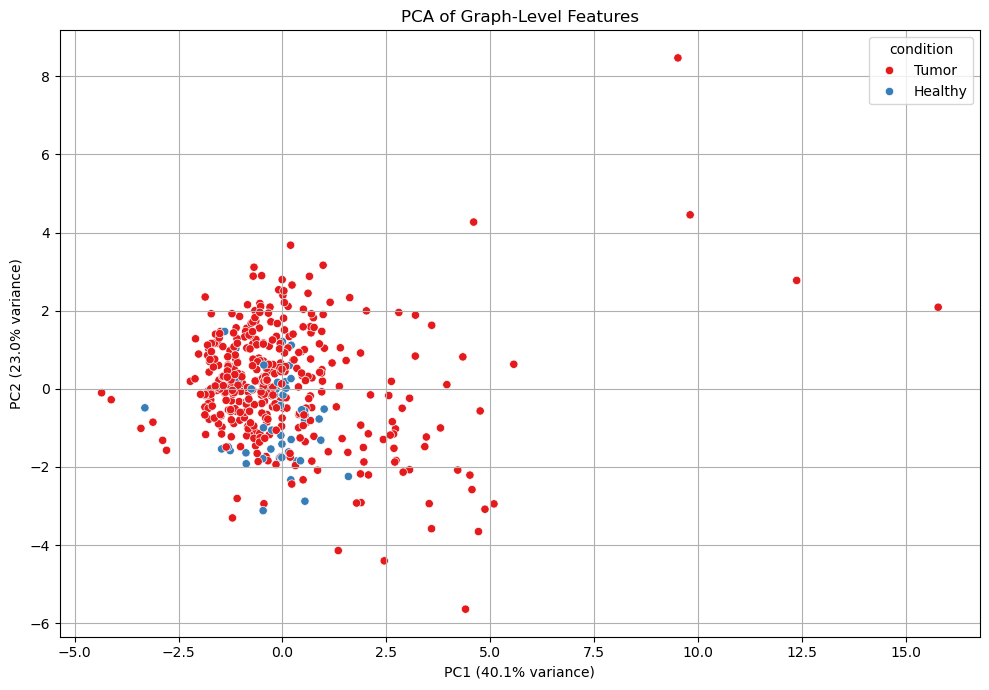

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='condition', palette='Set1')
plt.title('PCA of Graph-Level Features')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
# balancing data 
from sklearn.utils import resample

tumor_df = graph_df[graph_df['condition'] == 'Tumor']
healthy_df = graph_df[graph_df['condition'] == 'Healthy']

healthy_upsampled = resample(healthy_df,
                             replace=True,
                             n_samples=len(tumor_df),
                             random_state=42)

balanced_df = pd.concat([tumor_df, healthy_upsampled])

# Drop rows with missing 
graph_clean = balanced_df.dropna(subset=features)

# Extract and scale features
X = graph_clean[features].values
y = graph_clean['condition'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [46]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a dataframe for plotting
import pandas as pd

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'condition': y
})

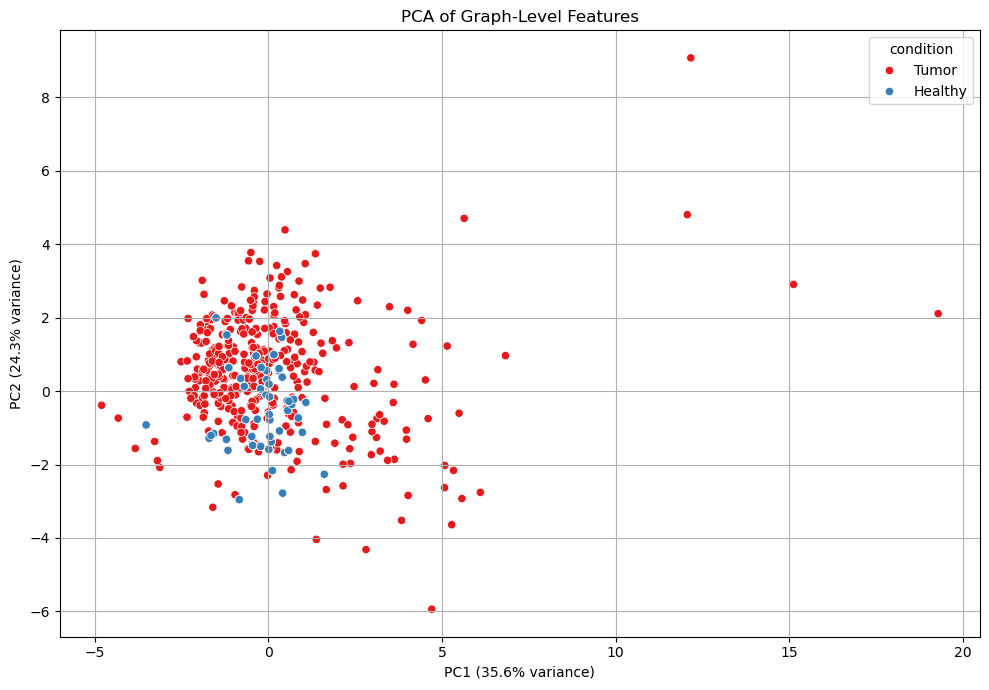

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='condition', palette='Set1')
plt.title('PCA of Graph-Level Features')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
# Loadings matrix: how much each feature contributes to PC1 and PC2
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

# Sort by absolute contribution to PC1
loadings['abs_PC1'] = loadings['PC1'].abs()
loadings['abs_PC2'] = loadings['PC2'].abs()

# Sort and show top contributors
print("\n Top contributors to PC1:")
print(loadings.sort_values(by='abs_PC1', ascending=False)[['PC1', 'PC2']])

print("\nTop contributors to PC2:")
print(loadings.sort_values(by='abs_PC2', ascending=False)[['PC1', 'PC2']])


 Top contributors to PC1:
                              PC1       PC2
global_clustering        0.546526 -0.029720
nodes                   -0.478393 -0.220248
edges                   -0.363411  0.037200
assortativity            0.357803 -0.020203
avg_degree               0.292444  0.440602
modularity               0.228555 -0.160458
diffusion_efficiency    -0.207052  0.567117
hierarchical_complexity -0.176136  0.151453
avg_local_clustering    -0.026539  0.619983

Top contributors to PC2:
                              PC1       PC2
avg_local_clustering    -0.026539  0.619983
diffusion_efficiency    -0.207052  0.567117
avg_degree               0.292444  0.440602
nodes                   -0.478393 -0.220248
modularity               0.228555 -0.160458
hierarchical_complexity -0.176136  0.151453
edges                   -0.363411  0.037200
global_clustering        0.546526 -0.029720
assortativity            0.357803 -0.020203


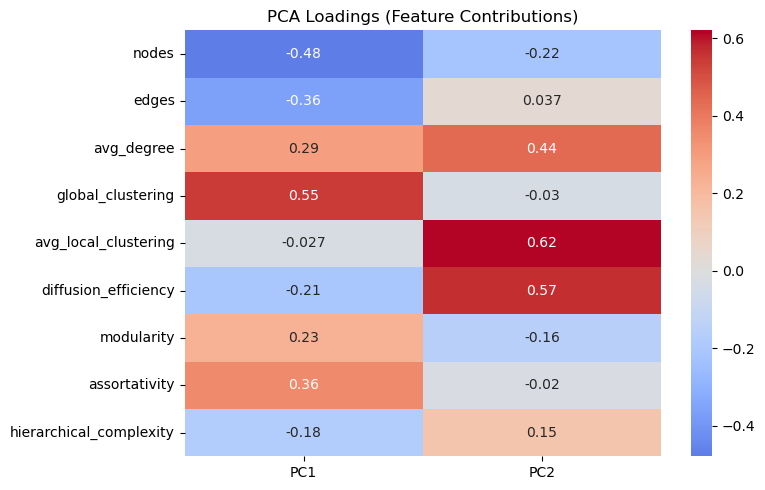

In [54]:
plt.figure(figsize=(8, 5))
sns.heatmap(loadings[['PC1', 'PC2']], annot=True, cmap="coolwarm", center=0)
plt.title("PCA Loadings (Feature Contributions)")
plt.tight_layout()
plt.show()